# Monte Carlo SIR / SEIR Model

## What is this?

This notebook simulates how a virus might spread through a population **after** it jumps from an animal to a human (a spillover event).

We use two classic disease spread models:

- **SIR** — every person is either **S**usceptible (healthy), **I**nfected, or **R**ecovered
- **SEIR** — same as SIR but adds an **E**xposed stage (infected but not yet contagious — like an incubation period)

## What is Monte Carlo?

We don't know exactly how contagious a new spillover virus will be, so instead of guessing one number, we run the simulation **1,000 times** with slightly different values each time. The result is a range of possible outcomes — a best case, worst case, and everything in between.

Think of it like rolling dice 1,000 times instead of once.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Settings

These are the knobs you can turn. Change these to model different scenarios.

In [33]:
N      = 10_000   # how many people are in the population
I0     = 1        # how many people are infected at the start
T      = 160      # how many days to simulate
N_SIMS = 1_000    # how many times to run the simulation
SEED   = 42       # makes random results reproducible

# beta  = how fast the virus spreads (higher = more contagious)
# gamma = how fast people recover (higher = shorter illness)
# sigma = how fast exposed people become contagious (higher = shorter incubation)
#
# Instead of one fixed number, each is drawn randomly from a distribution.
# scale roughly controls the average value (mean = shape x scale).
BETA_SHAPE,  BETA_SCALE  = 2.0, 0.25   # average beta  ~ 0.5
GAMMA_SHAPE, GAMMA_SCALE = 2.0, 0.10   # average gamma ~ 0.2  (5-day illness)
SIGMA_SHAPE, SIGMA_SCALE = 2.0, 0.20   # average sigma ~ 0.4  (2.5-day incubation)

## SIR Model

Each day, the model calculates:
1. How many **new people get infected** (depends on how many infected people are mixing with healthy people)
2. How many **infected people recover**

Everyone starts healthy except for 1 infected person. We watch what happens over 160 days.

In [34]:
def run_sir(beta, gamma, N, I0, T):
    """Runs one SIR simulation given a specific beta and gamma."""
    S, I, R = np.empty(T+1), np.empty(T+1), np.empty(T+1)
    S[0], I[0], R[0] = N - I0, I0, 0.0

    for t in range(T):
        # cap so new infections can't exceed the healthy people available
        new_infections = min(beta * S[t] * I[t] / N, S[t])
        # cap so recoveries can't exceed the sick people available
        new_recoveries = min(gamma * I[t], I[t])

        S[t+1] = S[t] - new_infections
        I[t+1] = I[t] + new_infections - new_recoveries
        R[t+1] = R[t] + new_recoveries

    return np.column_stack([S, I, R])


rng = np.random.default_rng(SEED)
betas_sir  = rng.gamma(BETA_SHAPE,  BETA_SCALE,  N_SIMS)
gammas_sir = rng.gamma(GAMMA_SHAPE, GAMMA_SCALE, N_SIMS)

sir_runs = np.stack([run_sir(b, g, N, I0, T) for b, g in zip(betas_sir, gammas_sir)])
print(f'Done! Shape of results: {sir_runs.shape}')  # (simulations, days, compartments)

Done! Shape of results: (1000, 161, 3)


### Summarize the results

With 1,000 runs we can show the **typical** outcome and the **uncertainty range**.

In [35]:
def summarize(runs, col):
    """Get median and 95% range across all simulations for one compartment."""
    data = runs[:, :, col]
    return pd.DataFrame({
        'day':    np.arange(runs.shape[1]),
        'median': np.median(data, axis=0),           # typical outcome
        'lower':  np.percentile(data,  2.5, axis=0), # low end (best case)
        'upper':  np.percentile(data, 97.5, axis=0), # high end (worst case)
    })

sir_S = summarize(sir_runs, 0)
sir_I = summarize(sir_runs, 1)
sir_R = summarize(sir_runs, 2)

# R0 = beta / gamma = the average number of people one sick person infects
# R0 > 1 means the outbreak grows; R0 < 1 means it fades out
R0_sir = betas_sir / gammas_sir
print(f'Median R0: {np.median(R0_sir):.2f}  (range: {np.percentile(R0_sir, 2.5):.2f} – {np.percentile(R0_sir, 97.5):.2f})')

Median R0: 2.42  (range: 0.27 – 22.18)


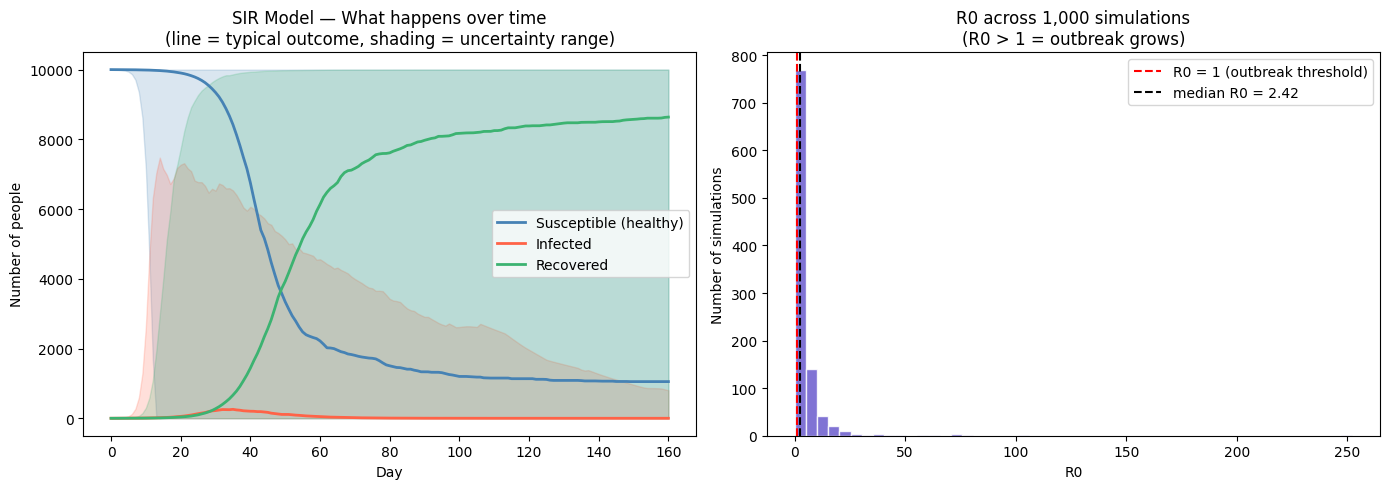

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: how each group changes over time
ax = axes[0]
for label, summary, color in [
    ('Susceptible (healthy)', sir_S, 'steelblue'),
    ('Infected',              sir_I, 'tomato'),
    ('Recovered',             sir_R, 'mediumseagreen'),
]:
    ax.plot(summary['day'], summary['median'], color=color, lw=2, label=label)
    ax.fill_between(summary['day'], summary['lower'], summary['upper'], color=color, alpha=0.2)
ax.set_title('SIR Model — What happens over time\n(line = typical outcome, shading = uncertainty range)')
ax.set_xlabel('Day')
ax.set_ylabel('Number of people')
ax.legend()

# Right: R0 distribution
ax2 = axes[1]
ax2.hist(R0_sir, bins=50, color='slateblue', edgecolor='white', alpha=0.85)
ax2.axvline(1, color='red', ls='--', lw=1.5, label='R0 = 1 (outbreak threshold)')
ax2.axvline(np.median(R0_sir), color='black', ls='--', label=f'median R0 = {np.median(R0_sir):.2f}')
ax2.set_title('R0 across 1,000 simulations\n(R0 > 1 = outbreak grows)')
ax2.set_xlabel('R0')
ax2.set_ylabel('Number of simulations')
ax2.legend()

plt.tight_layout()
plt.show()

## SEIR Model

The SEIR model adds an **Exposed** stage between getting infected and becoming contagious.

This is more realistic for zoonotic viruses, which often have an incubation period (think: you caught something but you're not sick yet and not spreading it yet).

- **S** → Susceptible (healthy)
- **E** → Exposed (infected but not yet contagious)
- **I** → Infectious (sick and spreading it)
- **R** → Recovered

Because of the extra delay, outbreaks in SEIR tend to peak **later and lower** than SIR.

In [37]:
def run_seir(beta, gamma, sigma, N, I0, T):
    """Runs one SEIR simulation. sigma controls how fast exposed people become infectious."""
    S, E, I, R = np.empty(T+1), np.empty(T+1), np.empty(T+1), np.empty(T+1)
    S[0], E[0], I[0], R[0] = N - I0, 0.0, I0, 0.0

    for t in range(T):
        # cap each flow so it can't exceed the group it's coming from
        new_exposed    = min(beta  * S[t] * I[t] / N, S[t])
        new_infectious = min(sigma * E[t], E[t])
        new_recovered  = min(gamma * I[t], I[t])

        S[t+1] = S[t] - new_exposed
        E[t+1] = E[t] + new_exposed    - new_infectious
        I[t+1] = I[t] + new_infectious - new_recovered
        R[t+1] = R[t] + new_recovered

    return np.column_stack([S, E, I, R])


rng2 = np.random.default_rng(SEED)
betas_seir  = rng2.gamma(BETA_SHAPE,  BETA_SCALE,  N_SIMS)
gammas_seir = rng2.gamma(GAMMA_SHAPE, GAMMA_SCALE, N_SIMS)
sigmas_seir = rng2.gamma(SIGMA_SHAPE, SIGMA_SCALE, N_SIMS)

seir_runs = np.stack([
    run_seir(b, g, s, N, I0, T)
    for b, g, s in zip(betas_seir, gammas_seir, sigmas_seir)
])
print(f'Done! Shape of results: {seir_runs.shape}')

Done! Shape of results: (1000, 161, 4)


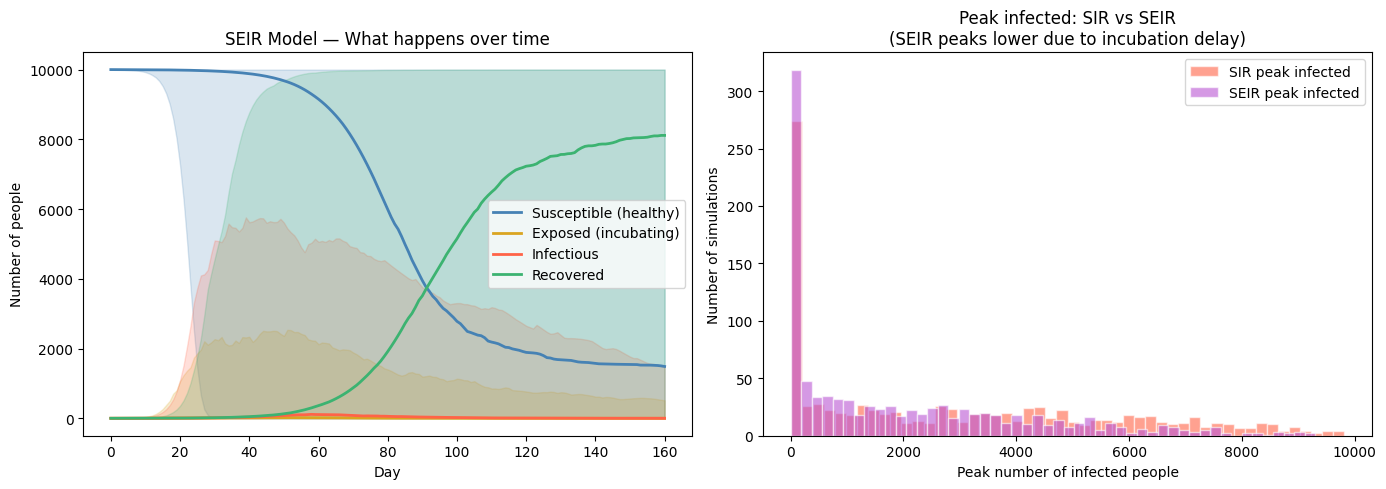

In [38]:
seir_S = summarize(seir_runs, 0)
seir_E = summarize(seir_runs, 1)
seir_I = summarize(seir_runs, 2)
seir_R = summarize(seir_runs, 3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: SEIR over time
ax = axes[0]
for label, summary, color in [
    ('Susceptible (healthy)', seir_S, 'steelblue'),
    ('Exposed (incubating)',  seir_E, 'goldenrod'),
    ('Infectious',            seir_I, 'tomato'),
    ('Recovered',             seir_R, 'mediumseagreen'),
]:
    ax.plot(summary['day'], summary['median'], color=color, lw=2, label=label)
    ax.fill_between(summary['day'], summary['lower'], summary['upper'], color=color, alpha=0.2)
ax.set_title('SEIR Model — What happens over time')
ax.set_xlabel('Day')
ax.set_ylabel('Number of people')
ax.legend()

# Right: peak infected comparison SIR vs SEIR
ax2 = axes[1]
ax2.hist(sir_runs[:, :, 1].max(axis=1),  bins=50, alpha=0.6, color='tomato',       label='SIR peak infected',  edgecolor='white')
ax2.hist(seir_runs[:, :, 2].max(axis=1), bins=50, alpha=0.6, color='mediumorchid',  label='SEIR peak infected', edgecolor='white')
ax2.set_title('Peak infected: SIR vs SEIR\n(SEIR peaks lower due to incubation delay)')
ax2.set_xlabel('Peak number of infected people')
ax2.set_ylabel('Number of simulations')
ax2.legend()

plt.tight_layout()
plt.show()

## Spillover Scenario: Does the host animal matter?

Here we connect the model to the **phylogenetic risk scores** from the genomics analysis.

The idea: a virus jumping from a **chimpanzee** (very close to humans genetically) is likely better adapted to human biology than one jumping from a **bat** (very distant). So we assume a higher phylogenetic risk score = higher transmission rate (beta).

We compare two spillover scenarios:
- **Bat host** — 95 million years from humans → low risk score
- **Primate host** — 6.9 million years from humans → high risk score

In [39]:
def run_spillover_scenario(phylo_risk_score, N=10_000, n_sims=1_000, seed=None):
    """
    Run a SEIR simulation where beta is scaled by how closely related
    the host animal is to humans.

    phylo_risk_score: a number 0-1 from NCBIPhyloEstimator
        (calculated as: np.exp(-divergence_mya / 50))
        closer to 1 = host is more closely related to humans
    """
    # higher risk score = higher average beta (more contagious after spillover)
    beta_mean  = 0.3 + 0.4 * phylo_risk_score
    beta_scale = beta_mean / 2.0

    rng = np.random.default_rng(seed)
    betas  = rng.gamma(2.0,         beta_scale,  n_sims)
    gammas = rng.gamma(GAMMA_SHAPE, GAMMA_SCALE, n_sims)
    sigmas = rng.gamma(SIGMA_SHAPE, SIGMA_SCALE, n_sims)

    runs = np.stack([
        run_seir(b, g, s, N, I0, T)
        for b, g, s in zip(betas, gammas, sigmas)
    ])
    return runs


# phylo_risk_score = np.exp(-divergence_mya / 50)
bat_risk     = np.exp(-95  / 50)  # ~0.15
primate_risk = np.exp(-6.9 / 50)  # ~0.87

bat_runs     = run_spillover_scenario(bat_risk,     seed=42)
primate_runs = run_spillover_scenario(primate_risk, seed=42)

print(f'Bat spillover     — risk score: {bat_risk:.2f} | median peak infected: {np.median(bat_runs[:,:,2].max(axis=1)):.0f}')
print(f'Primate spillover — risk score: {primate_risk:.2f} | median peak infected: {np.median(primate_runs[:,:,2].max(axis=1)):.0f}')

Bat spillover     — risk score: 0.15 | median peak infected: 456
Primate spillover — risk score: 0.87 | median peak infected: 1724


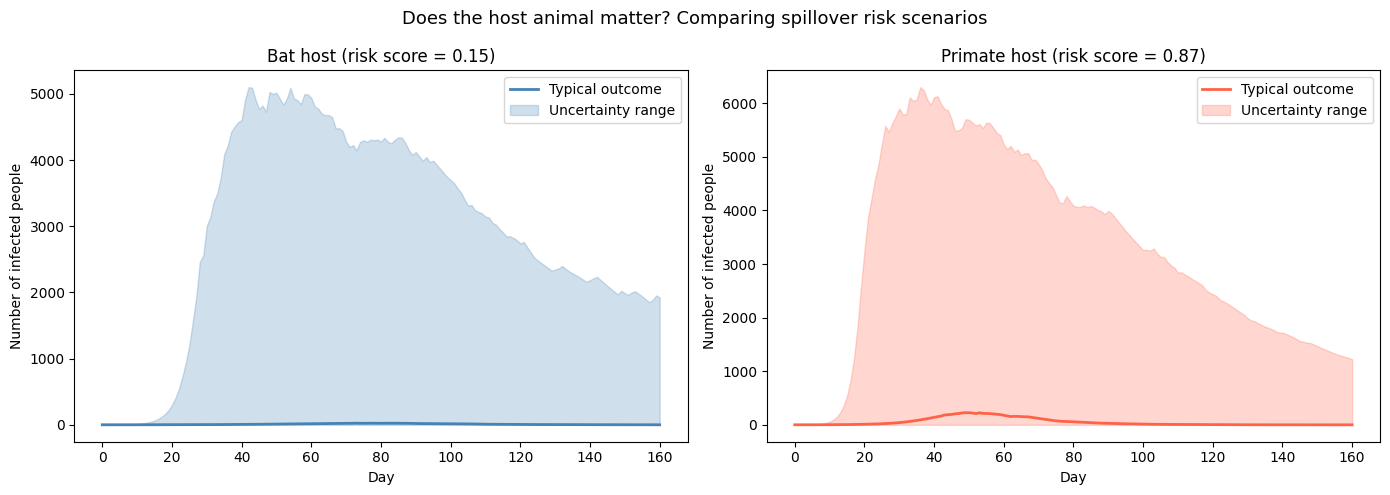

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, runs, label, color in [
    (axes[0], bat_runs,     f'Bat host (risk score = {bat_risk:.2f})',      'steelblue'),
    (axes[1], primate_runs, f'Primate host (risk score = {primate_risk:.2f})', 'tomato'),
]:
    I_data = runs[:, :, 2]  # infected compartment
    days   = np.arange(T + 1)

    ax.plot(days, np.median(I_data, axis=0), color=color, lw=2, label='Typical outcome')
    ax.fill_between(days,
                    np.percentile(I_data,  2.5, axis=0),
                    np.percentile(I_data, 97.5, axis=0),
                    color=color, alpha=0.25, label='Uncertainty range')
    ax.set_title(label)
    ax.set_xlabel('Day')
    ax.set_ylabel('Number of infected people')
    ax.legend()

plt.suptitle('Does the host animal matter? Comparing spillover risk scenarios', fontsize=13)
plt.tight_layout()
plt.show()